In [73]:
import torch
from pathlib import Path
import sys

project_root = Path().resolve().parent
sys.path.append(str(project_root))

from src.models import ImageCaptionModel
from src.data.vocab import Vocabulary
from src.data.extract_features import extract_features_from_image, load_encoder
from src.utils.config import *
from src.data.dataset import COCOCaptionDataset

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


Load vocab and model

In [74]:
vocab = Vocabulary.load(project_root / VOCAB_FILE)
print("Vocab size:", len(vocab))

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ImageCaptionModel(vocab_size=len(vocab), num_layers=NUM_LAYERS).to(device)
# model.load_state_dict(torch.load(project_root / MODEL_FILE, map_location=device))
model.load_state_dict(torch.load(project_root / TRAIN_DIR / "trained_model.pt", map_location=device))
model.eval()

print("Model loaded")

Vocab size: 2697
Model loaded


Load encoder

In [75]:
encoder, enc_device = load_encoder()

Generate caption on image

In [76]:
image_path = "../data/raw/images/000000000139.jpg"

feature = extract_features_from_image(
    image_path,
    encoder=encoder,
    device=enc_device
)

caption = model.generate_caption(feature, vocab)

print(f'Generated caption: "{" ".join(caption)}"')

Generated caption: "a woman standing in a kitchen by a window"


Remove eos

In [77]:
def clean_caption(tokens):
    if "<eos>" in tokens:
        tokens = tokens[:tokens.index("<eos>")]
    return tokens

caption = clean_caption(caption)

Put caption on image

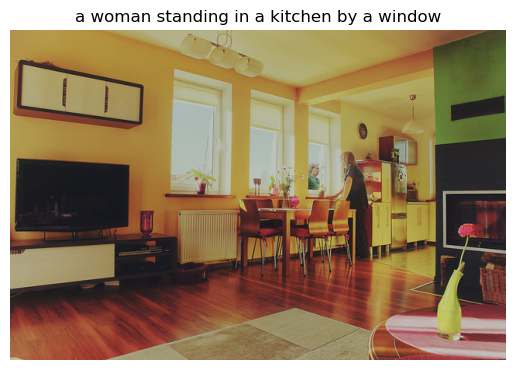

In [78]:
from PIL import Image
import matplotlib.pyplot as plt

img = Image.open(image_path)

plt.imshow(img)
plt.axis("off")
plt.title(" ".join(caption))
plt.show()